# Variational Fast-Forwarding for Quantum Simulation

This tutorial demonstrates **Variational Fast-Forwarding (VFF)**, a quantum machine learning
technique for simulating quantum systems *beyond* the coherence time of near-term hardware.

Using the `h_molecule_evolution_data` dataset from `qiskit-machine-learning` we will:

1. Configure the molecule, qubit count, and simulator settings
2. Visualise the Trotterised evolution circuit and the VFF ansatz circuit
3. Generate short-term (noisy) and long-term (ideal) evolution data
4. Train the VFF model on short-term data and evaluate its extrapolation

**References:**
- Cîrstoiu et al., *npj Quantum Information* (2020). [arXiv:1910.04292](https://arxiv.org/abs/1910.04292)
- Filip et al., *Quantum* (2024). [arXiv:2211.16097](https://arxiv.org/abs/2211.16097)

## 1. Background

### The Quantum Simulation Problem

Simulating a quantum system with Hamiltonian $H$ requires applying $U(t) = e^{-iHt}$.
Near-term devices can faithfully implement $U(t)$ only for short times $t$ before noise
and decoherence degrade the result. VFF side-steps this limit by *learning* to fast-forward.

### Variational Fast-Forwarding

VFF trains a parameterised circuit $W(t;\theta,\omega)$ to approximate $U(t)$ for **all**
times from short-time training data only:

$$W(t;\theta,\omega) \approx U(t) = e^{-iHt}$$

The ansatz mirrors the spectral decomposition $H = V D V^\dagger$:

$$W(t;\theta,\omega) = V(\theta)\; P(\omega,t)\; V^\dagger(\theta)$$

| Block | Role | Implementation |
|-------|------|----------------|
| $V^\dagger(\theta)$ | rotate to approximate eigenbasis | EfficientSU2 (inverse) |
| $P(\omega,t)$ | diagonal phase evolution | $R_z(\omega_k t)$ per qubit |
| $V(\theta)$ | rotate back | EfficientSU2 |

Training minimises the average infidelity over the noisy training states:

$$\mathcal{L}(\theta,\omega) = 1 - \frac{1}{N}\sum_{i=1}^{N} |\langle Y_i | W(t_i;\theta,\omega)|\psi_{HF}\rangle|^2$$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(".").resolve()))  # local h_molecule_evolution.py

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit.circuit import QuantumCircuit, ParameterVector, Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import Statevector, state_fidelity

from h_molecule_evolution import h_molecule_evolution_data, _evolution_circuit

## 2. Configuration

Edit the cell below before running the rest of the notebook.

| Parameter | Options | Description |
|-----------|---------|-------------|
| `MOLECULE` | `"H2"` (4 qubits) · `"H3"` (6 qubits) | Hydrogen molecule to simulate |
| `NOISE_MODE` | `"noiseless"` · `"reduced"` · IBM backend name | Noise level for training data |
| `DELTA_T` | float > 0 | Time step (atomic units; 1 a.u. ≈ 2.42×10⁻¹⁷ s) |
| `TRAIN_END` | int ≥ 1 | Number of short-term training steps |
| `TEST_START` | int > `TRAIN_END` | Start of long-term test range |
| `TEST_END` | int > `TEST_START` | End of long-term test range |
| `REPS` | int ≥ 1 | VFF ansatz depth (more reps → more expressive, slower to train) |

In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────
MOLECULE   = "H2"         # "H2" (4 qubits) or "H3" (6 qubits)
NOISE_MODE = "noiseless"  # "noiseless", "reduced", or an IBM backend name
DELTA_T    = 0.1          # time step in atomic units
TRAIN_END  = 10           # short-term training range: t = 0 … TRAIN_END * DELTA_T
TEST_START = 11           # long-term test range start
TEST_END   = 30           # long-term test range end
REPS       = 2            # VFF ansatz repetitions
SEED       = 42           # random seed for reproducibility
# ─────────────────────────────────────────────────────────────────────────────

N_QUBITS = {"H2": 4, "H3": 6}[MOLECULE]
print(f"Molecule : {MOLECULE}  ({N_QUBITS} qubits)")
print(f"Simulator: {NOISE_MODE}")
print(f"Training : t = 0 … {TRAIN_END * DELTA_T:.2f} a.u.  ({TRAIN_END + 1} points)")
print(f"Test     : t = {TEST_START * DELTA_T:.2f} … {TEST_END * DELTA_T:.2f} a.u.  ({TEST_END - TEST_START + 1} points)")

Molecule : H2  (4 qubits)
Simulator: noiseless
Training : t = 0 … 1.00 a.u.  (11 points)
Test     : t = 1.10 … 3.00 a.u.  (20 points)


## 3. Circuit Diagrams

### 3.1 Trotterised Evolution Circuit $U(\Delta t)$

The dataset generates training states using a 2nd-order Suzuki-Trotter approximation of
$e^{-iH\Delta t}$, transpiled to native gates.  Each training step applies this circuit once
to the current state, accumulating noise realistically.

The diagram below shows the circuit for **one** time step $\Delta t$ with the chosen molecule.

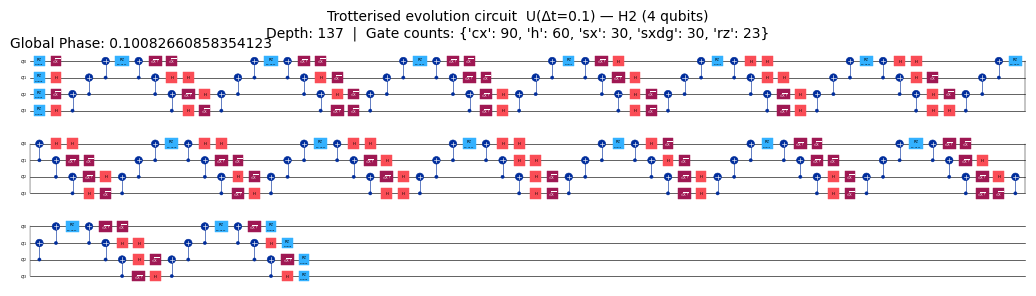

In [3]:
qc_evo, time_param, hamiltonian = _evolution_circuit(MOLECULE)
qc_step = qc_evo.assign_parameters({time_param: DELTA_T})

fig, ax = plt.subplots(figsize=(12, 3))
qc_step.draw(output="mpl", style="iqp", fold=60, ax=ax)
ax.set_title(
    f"Trotterised evolution circuit  U(\u0394t={DELTA_T}) — {MOLECULE} ({N_QUBITS} qubits)"
    f"\nDepth: {qc_step.depth()}  |  Gate counts: {dict(qc_step.count_ops())}",
    fontsize=10, pad=8,
)
plt.tight_layout()
plt.show()

### 3.2 VFF Ansatz Circuit $W(t;\theta,\omega)$

The ansatz has three sections separated by barriers:

1. **$V^\dagger(\theta)$** — EfficientSU2 (inverse), maps to approximate eigenbasis
2. **$P(\omega,t)$** — $R_z(\omega_k \cdot t)$ on each qubit (learned frequency per qubit)
3. **$V(\theta)$** — EfficientSU2, maps back from eigenbasis

$\theta$ and $\omega$ are shared between sections 1 and 3 (same parameter objects),
so the circuit has `EfficientSU2.num_parameters + N_QUBITS` trainable scalars total.

/var/folders/tt/f0lw_k_d15v3w5wjjv20m2c00000gn/T/ipykernel_11147/3633542595.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  v = EfficientSU2(n_qubits, reps=reps, entanglement="full", parameter_prefix="θ")


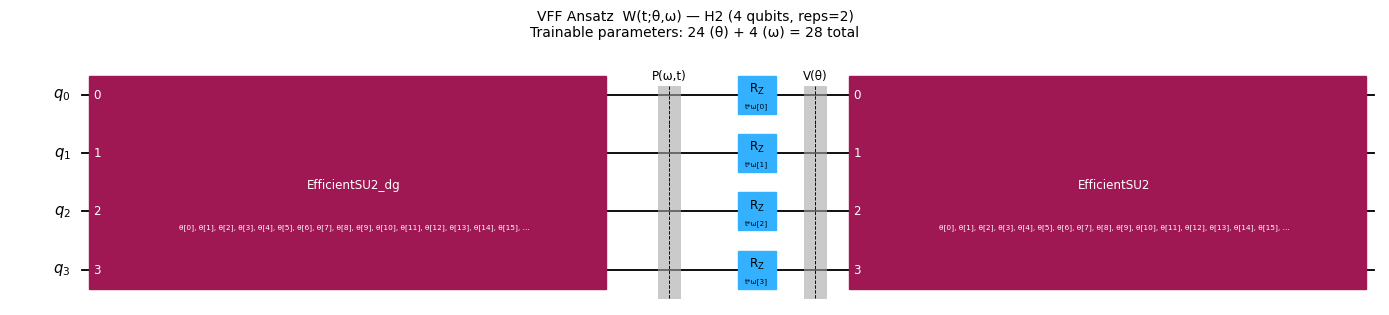

In [4]:
def build_vff_ansatz(n_qubits: int, reps: int = 2):
    """Return (circuit, v_params, omega_params, t_param)."""
    t = Parameter("t")
    omega = ParameterVector("ω", n_qubits)
    v = EfficientSU2(n_qubits, reps=reps, entanglement="full", parameter_prefix="θ")

    qc = QuantumCircuit(n_qubits, name="W(t;θ,ω)")
    qc.compose(v.inverse(), inplace=True)       # V†(θ)
    qc.barrier(label="P(ω,t)")
    for k in range(n_qubits):
        qc.rz(omega[k] * t, k)                  # diagonal phase
    qc.barrier(label="V(θ)")
    qc.compose(v, inplace=True)                 # V(θ)

    return qc, list(v.parameters), list(omega), t


qc_vff, v_params, omega_params, t_param = build_vff_ansatz(N_QUBITS, reps=REPS)
n_trainable = len(v_params) + len(omega_params)

fig, ax = plt.subplots(figsize=(14, max(3, N_QUBITS)))
qc_vff.draw(output="mpl", style="iqp", fold=80, ax=ax)
ax.set_title(
    f"VFF Ansatz  W(t;θ,ω) — {MOLECULE} ({N_QUBITS} qubits, reps={REPS})"
    f"\nTrainable parameters: {len(v_params)} (θ) + {len(omega_params)} (ω) = {n_trainable} total",
    fontsize=10, pad=8,
)
plt.tight_layout()
plt.show()

## 4. Generate the Benchmarking Dataset

The function returns:

| Return value | Description |
|---|---|
| `psi_hf` | Hartree-Fock state $|\psi_{HF}\rangle$ (lowest orbital occupation) |
| `x_train`, `y_train` | Timestamps and **noisy** short-term evolved states |
| `x_test`, `y_test` | Timestamps and **ideal** long-term evolved states |

In [5]:
psi_hf, x_train, y_train, x_test, y_test = h_molecule_evolution_data(
    delta_t=DELTA_T,
    train_end=TRAIN_END,
    test_start=TEST_START,
    test_end=TEST_END,
    molecule=MOLECULE,
    noise_mode=NOISE_MODE,
    formatting="statevector",
)

print(f"Hartree-Fock state : {psi_hf}")
print(f"Training timestamps: {x_train.shape}  [{x_train[0]:.3f} … {x_train[-1]:.3f}] a.u.")
print(f"Training states    : {len(y_train)} Statevectors ({2**N_QUBITS}-dim)")
print(f"Test timestamps    : {x_test.shape}  [{x_test[0]:.3f} … {x_test[-1]:.3f}] a.u.")
print(f"Test states        : {len(y_test)} Statevectors ({2**N_QUBITS}-dim)")

Hartree-Fock state : Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2))
Training timestamps: (11,)  [0.000 … 1.000] a.u.
Training states    : 11 Statevectors (16-dim)
Test timestamps    : (20,)  [1.100 … 3.000] a.u.
Test states        : 20 Statevectors (16-dim)


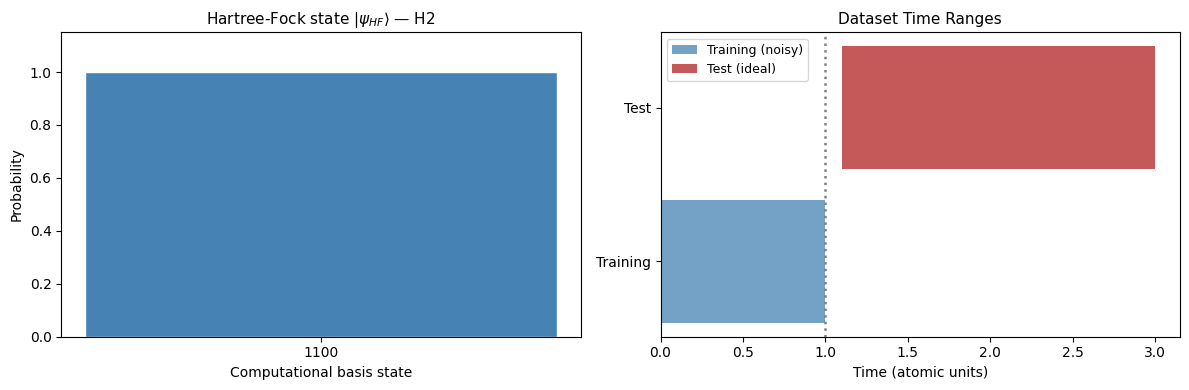

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Hartree-Fock occupation probabilities
probs  = psi_hf.probabilities()
labels = [format(i, f"0{N_QUBITS}b") for i in range(2**N_QUBITS)]
nz     = [(l, p) for l, p in zip(labels, probs) if p > 1e-6]
ax1.bar(*zip(*nz), color="steelblue", edgecolor="white", width=0.5)
ax1.set_title(f"Hartree-Fock state $|\\psi_{{HF}}\\rangle$ — {MOLECULE}", fontsize=11)
ax1.set_xlabel("Computational basis state", fontsize=10)
ax1.set_ylabel("Probability", fontsize=10)
ax1.set_ylim(0, 1.15)

# Time range overview
ax2.barh(["Training"], [x_train[-1] - x_train[0]], left=x_train[0],
         color="steelblue", alpha=0.75, label="Training (noisy)")
ax2.barh(["Test"], [x_test[-1] - x_test[0]], left=x_test[0],
         color="firebrick", alpha=0.75, label="Test (ideal)")
ax2.axvline(x_train[-1], color="gray", linestyle=":", linewidth=1.8)
ax2.set_xlabel("Time (atomic units)", fontsize=10)
ax2.set_title("Dataset Time Ranges", fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Training

### 5.1 Loss Function

All trainable values are packed into a single flat vector
`params = [θ₀ … θₙ, ω₀ … ωₖ]`.  The loss is average infidelity over training times:

$$\mathcal{L} = \frac{1}{N+1}\sum_{i=0}^{N}\left(1 - |\langle Y_i | W(t_i;\theta,\omega)|\psi_{HF}\rangle|^2\right)$$

Optimisation uses COBYLA — gradient-free, works well up to ~30 parameters.

In [7]:
def vff_loss(params, qc, v_params, omega_params, t_param, psi_hf, x_train, y_train, history):
    n_v = len(v_params)
    param_dict = {p: params[i]       for i, p in enumerate(v_params)}
    param_dict.update({p: params[n_v + i] for i, p in enumerate(omega_params)})

    total = 0.0
    for t_val, y_target in zip(x_train, y_train):
        param_dict[t_param] = float(t_val)
        psi_out = psi_hf.evolve(qc.assign_parameters(param_dict))
        total  += 1.0 - state_fidelity(psi_out, y_target, validate=False)

    loss = total / len(x_train)
    history.append(loss)
    return loss

In [8]:
np.random.seed(SEED)
x0      = np.random.uniform(-np.pi, np.pi, n_trainable)
history = []

result = minimize(
    vff_loss,
    x0,
    args=(qc_vff, v_params, omega_params, t_param, psi_hf, x_train, y_train, history),
    method="COBYLA",
    options={"maxiter": 1000, "rhobeg": 0.5},
)

theta_opt = result.x
status    = "converged" if result.success else "reached max iterations"
print(f"Optimisation {status} after {len(history)} evaluations")
print(f"Final training infidelity : {history[-1]:.4f}")

Optimisation reached max iterations after 1000 evaluations
Final training infidelity : 0.0257


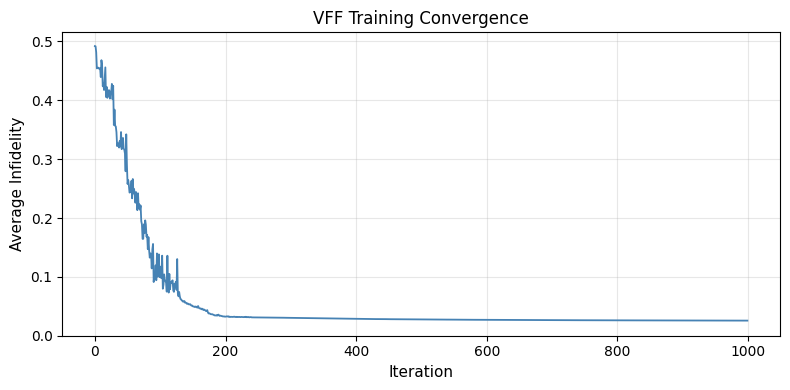

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, color="steelblue", linewidth=1.3)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Average Infidelity", fontsize=11)
ax.set_title("VFF Training Convergence", fontsize=12)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluation: Extrapolation to Long Times

With optimised $\theta^*, \omega^*$ we compute the fidelity

$$F(t) = |\langle U(t)\psi_{HF} | W(t;\theta^*,\omega^*)\psi_{HF}\rangle|^2$$

over both training and test timestamps.  High fidelity in the **test region**
(right of the dashed boundary) demonstrates successful extrapolation beyond
the coherence time.

In [10]:
def compute_fidelities(params, qc, v_params, omega_params, t_param, psi_hf, timestamps, targets):
    n_v = len(v_params)
    param_dict = {p: params[i]       for i, p in enumerate(v_params)}
    param_dict.update({p: params[n_v + i] for i, p in enumerate(omega_params)})
    return np.array([
        state_fidelity(
            psi_hf.evolve(qc.assign_parameters({**param_dict, t_param: float(t_val)})),
            y_target,
            validate=False,
        )
        for t_val, y_target in zip(timestamps, targets)
    ])


train_fidelities = compute_fidelities(
    theta_opt, qc_vff, v_params, omega_params, t_param, psi_hf, x_train, y_train
)
test_fidelities = compute_fidelities(
    theta_opt, qc_vff, v_params, omega_params, t_param, psi_hf, x_test, y_test
)

print(f"Mean training fidelity : {train_fidelities.mean():.4f} ± {train_fidelities.std():.4f}")
print(f"Mean test fidelity     : {test_fidelities.mean():.4f} ± {test_fidelities.std():.4f}")

Mean training fidelity : 0.9743 ± 0.0304
Mean test fidelity     : 0.5332 ± 0.0832


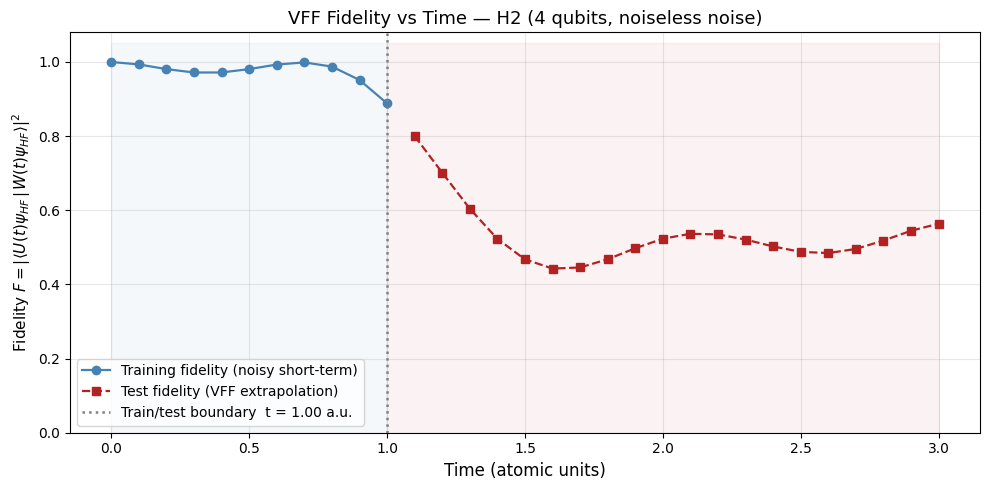

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_train, train_fidelities, "o-", color="steelblue", markersize=6,
        label="Training fidelity (noisy short-term)", linewidth=1.6)
ax.plot(x_test, test_fidelities,  "s--", color="firebrick", markersize=6,
        label="Test fidelity (VFF extrapolation)", linewidth=1.6)

boundary = x_train[-1]
ax.axvline(boundary, color="gray", linestyle=":", linewidth=1.8,
           label=f"Train/test boundary  t = {boundary:.2f} a.u.")
ax.fill_betweenx([0, 1.05], 0, boundary,
                 alpha=0.05, color="steelblue")
ax.fill_betweenx([0, 1.05], boundary, x_test[-1],
                 alpha=0.05, color="firebrick")

ax.set_xlabel("Time (atomic units)", fontsize=12)
ax.set_ylabel(
    r"Fidelity $F = |\langle U(t)\psi_{HF}\,|\,W(t)\psi_{HF}\rangle|^2$",
    fontsize=11,
)
ax.set_title(
    f"VFF Fidelity vs Time — {MOLECULE} ({N_QUBITS} qubits, {NOISE_MODE} noise)",
    fontsize=13,
)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary

In this tutorial we:

1. **Configured** the simulation (molecule, qubit count, noise model) in one cell
2. **Visualised** the Trotterised $U(\Delta t)$ circuit and the VFF ansatz $W(t;\theta,\omega)$
3. **Generated** benchmarking data with `h_molecule_evolution_data`
4. **Trained** the VFF model using COBYLA on noisy short-term states
5. **Evaluated** fidelity — including in the extrapolation regime beyond the training range

### Things to try

- Switch `MOLECULE` to `"H3"` for a 6-qubit system (longer to run)
- Set `NOISE_MODE = "reduced"` to use a low depolarising noise model for training
- Increase `REPS` for a more expressive ansatz
- Reduce `TRAIN_END` to see how few training points VFF needs to extrapolate

### References

- Cîrstoiu, C. et al. *Variational fast forwarding for quantum simulation beyond the coherence time*. npj Quantum Inf **6**, 82 (2020). [arXiv:1910.04292](https://arxiv.org/abs/1910.04292)
- Filip, M-A. et al. *Variational Phase Estimation with Variational Fast Forwarding*. Quantum **8**, 1278 (2024). [arXiv:2211.16097](https://arxiv.org/abs/2211.16097)
- Dataset API: `qiskit_machine_learning.datasets.h_molecule_evolution_data`